# S&P 500 vs Stock: Price Comparison Since 2010

In this notebook, we compare the historical price performance of the **S&P 500** and a selected stock (**TICKER**) from 2010 to today.  

We will:
- Download historical closing prices using `yfinance`
- Plot both series on a dual-axis chart
- Calculate daily percentage changes for further analysis


In [1]:
# --- Imports ---
from src.technical_setup import *
ticker = TICKER
start = START_DATE


c:\Users\Linus\Desktop\Python\src\technical_setup.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(TICKER, start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed
c:\Users\Linus\Desktop\Python\src\technical_setup.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed


## Function: Download Historical Data

We define a helper function to download historical **closing prices** from Yahoo Finance.


In [2]:
def download_data(ticker: str, start: str = "2010-01-01"):
    """
    Download historical closing prices from Yahoo Finance.

    Parameters
    ----------
    ticker : str
        The stock symbol, e.g., 'MSFT' or '^GSPC'. 
    start : str, optional
        Start date in 'YYYY-MM-DD' format. Default is '2010-01-01'. 

    Returns
    -------
    pd.Series
        Historical closing prices as a Pandas Series.
    """
    data = yf.download(ticker, start=start)["Close"]
    return data


## Dual-Axis Price Plot

We plot the **S&P 500** on the primary axis (blue) and the selected stock on the secondary axis (red).  
This allows easy visual comparison of their price movements over time.


In [3]:
def plot_price_comparison(asset1, asset2, label1="S&P 500", label2="Stock", title="Price Comparison (2010–Today)", save_path=None):
    """
    Plots two assets on a dual-axis chart for easy comparison.

    Parameters
    ----------
    asset1 : pd.Series
        First asset (primary y-axis)
    asset2 : pd.Series
        Second asset (secondary y-axis)
    label1 : str
        Label for first asset
    label2 : str
        Label for second asset
    title : str
        Chart title
    """
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.plot(asset1, color='blue', label=label1)
    ax.set_ylabel(label1, color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    
    ax2 = ax.twinx()
    ax2.plot(asset2, color='red', label=label2)
    ax2.set_ylabel(label2, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax.set_title(title, fontsize=14)
    plt.show()

    # Save plot if path provided
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')


## Download Data

We download the S&P 500 index and the selected stock.

In [4]:
# --- Load data ---
sp500 = download_data("^GSPC")
stock = download_data(ticker)

# Assign assets for plotting
asset1 = sp500
asset2 = stock


C:\Users\Linus\AppData\Local\Temp\ipykernel_6148\1393457125.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start)["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Linus\AppData\Local\Temp\ipykernel_6148\1393457125.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start)["Close"]
[*********************100%***********************]  1 of 1 completed


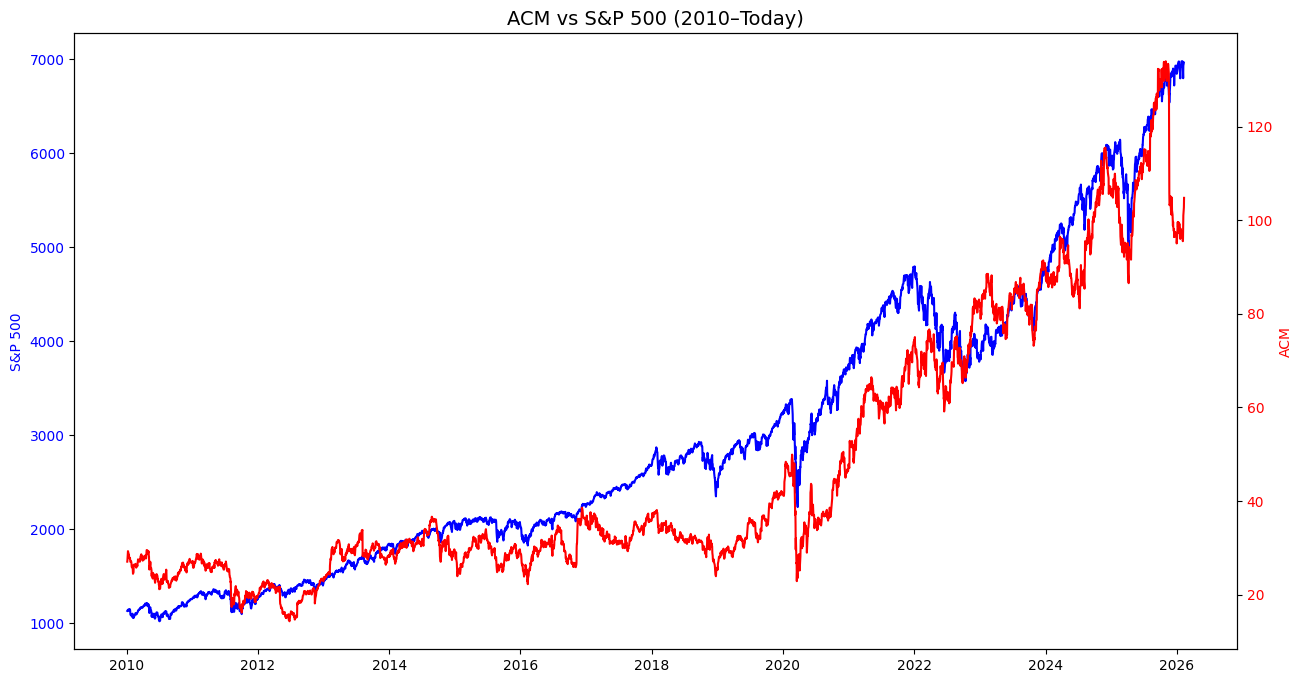

In [5]:
# --- Example usage ---
plot_price_comparison(
    asset1, asset2, label1="S&P 500", label2=ticker,
    title=f"{ticker} vs S&P 500 (2010–Today)",
    save_path=f"figures/{ticker}_vs_SP500.png"
)